<h2>Nassau Candy Distributor — Shipping Route Analysis<h2>
<h3>Section 1: Data Loading & Exploration<h3>

In [65]:
#importing python libraries
import pandas as pd

In [66]:
#Load dataset
df=pd.read_csv("../Nassau Candy Distributor.csv")

In [67]:
#brief look of dataset
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [68]:
#dimensions of dataset
df.shape

(10194, 18)

In [69]:
#All features of dataset
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='object')

In [70]:
#Basic structure of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [71]:
#checking for duplicates
df.duplicated().sum()

np.int64(0)

In [72]:
#Basic statistics
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [73]:
# What are the different shipping methods?
print('Ship Modes:')
print(df['Ship Mode'].unique())

Ship Modes:
['Standard Class' 'First Class' 'Second Class' 'Same Day']


In [74]:
# What regions do customers belong to?
print('Regions:')
print(df['Region'].unique())


Regions:
['Interior' 'Atlantic' 'Gulf' 'Pacific']


In [75]:
# What product divisions exist?
print('Divisions:')
print(df['Division'].unique())

Divisions:
['Chocolate' 'Other' 'Sugar']


In [76]:
# What are all 15 products?
print('Products:')
print(df['Product Name'].unique())

Products:
['Wonka Bar - Milk Chocolate' 'Wonka Bar - Triple Dazzle Caramel'
 'Wonka Bar - Nutty Crunch Surprise' 'Wonka Bar -Scrumdiddlyumptious'
 'Wonka Bar - Fudge Mallows' 'Wonka Gum' 'Kazookles' 'Lickable Wallpaper'
 'Fizzy Lifting Drinks' 'Laffy Taffy' 'SweeTARTS' 'Nerds' 'Hair Toffee'
 'Everlasting Gobstopper' 'Fun Dip']


In [77]:
# How many orders per Ship Mode?
print('Order count by Ship Mode:')
print(df['Ship Mode'].value_counts())

Order count by Ship Mode:
Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64


In [78]:
# How many orders per Region?
print('Order count by Region:')
print(df['Region'].value_counts())

Order count by Region:
Region
Pacific     3253
Atlantic    2986
Interior    2335
Gulf        1620
Name: count, dtype: int64


In [79]:
# How many unique states are there?
print('Number of unique states:', df['State/Province'].nunique())

Number of unique states: 59


<h3>Section 2: Data Cleaning & Feature Engineering</h3>

In [80]:
# Step 1: Convert date columns from text to proper dates
# dayfirst=True means the format is DD-MM-YYYY
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)


In [81]:
# Step 2: Calculate raw difference in days
df['Raw Diff'] = (df['Ship Date'] - df['Order Date']).dt.days

In [82]:
# Step 3: Fix the lead time using modulo 365
# This removes the extra years and gives us actual shipping days
df['Lead Time'] = df['Raw Diff'] % 365

In [83]:
# Step 4: Check the result
print('Lead Time range:', df['Lead Time'].min(), 'to', df['Lead Time'].max(), 'days')
print('Average Lead Time:', df['Lead Time'].mean().round(1), 'days')

Lead Time range: 174 to 185 days
Average Lead Time: 178.3 days


In [84]:
# Step 5: Check for any bad data
print('Negative lead times:', (df['Lead Time'] < 0).sum())
print('Zero lead times:', (df['Lead Time'] == 0).sum())

Negative lead times: 0
Zero lead times: 0


In [85]:
# Step 1: Create a dictionary — product name maps to factory name
product_to_factory = {
    'Wonka Bar - Nutty Crunch Surprise':   "Lot's O' Nuts",
    'Wonka Bar - Fudge Mallows':            "Lot's O' Nuts",
    'Wonka Bar -Scrumdiddlyumptious':       "Lot's O' Nuts",
    'Wonka Bar - Milk Chocolate':           "Wicked Choccy's",
    'Wonka Bar - Triple Dazzle Caramel':    "Wicked Choccy's",
    'Laffy Taffy':                          'Sugar Shack',
    'SweeTARTS':                            'Sugar Shack',
    'Nerds':                                'Sugar Shack',
    'Fun Dip':                              'Sugar Shack',
    'Fizzy Lifting Drinks':                 'Sugar Shack',
    'Everlasting Gobstopper':               'Secret Factory',
    'Lickable Wallpaper':                   'Secret Factory',
    'Wonka Gum':                            'Secret Factory',
    'Hair Toffee':                          'The Other Factory',
    'Kazookles':                            'The Other Factory',
}


In [86]:
# Step 2: Create the Factory column using the dictionary
df['Factory'] = df['Product Name'].map(product_to_factory)

In [87]:
# Step 3: Create route columns
# Route by Region: e.g. Sugar Shack -> Atlantic
df['Route Region'] = df['Factory'] + ' -> ' + df['Region']

In [88]:
# Route by State: e.g. Sugar Shack -> Texas
df['Route State'] = df['Factory'] + ' -> ' + df['State/Province']

In [89]:
# Step 4: Add year and month columns (useful for trends later)
df['Order Year']  = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month

In [90]:
# Step 5: Add a Delay flag
# An order is delayed if lead time is above average + 1 standard deviation
threshold = df['Lead Time'].mean() + df['Lead Time'].std()
df['Is Delayed'] = df['Lead Time'] > threshold
print('Delay threshold:', round(threshold, 1), 'days')
print('Total delayed orders:', df['Is Delayed'].sum())
print('Delay rate:', round(df['Is Delayed'].mean() * 100, 1), '%')

Delay threshold: 180.1 days
Total delayed orders: 1045
Delay rate: 10.3 %


In [91]:
# Step 6: Verify — check factory column
print('Factory counts:')
print(df['Factory'].value_counts())

Factory counts:
Factory
Lot's O' Nuts        5692
Wicked Choccy's      4152
Secret Factory        217
The Other Factory     100
Sugar Shack            33
Name: count, dtype: int64


In [92]:
# Step 7: Save
df.to_csv('../nassau_features.csv', index=False)
print('Features saved!')

Features saved!


<h3>Section 3: KPI Calculation</h3>

In [93]:

# ── KPI TABLE 1: By Route (Factory → Region) ──
route_kpi = df.groupby('Route Region').agg(
    Total_Orders   = ('Lead Time', 'count'),
    Avg_Lead_Time  = ('Lead Time', 'mean'),
    Min_Lead_Time  = ('Lead Time', 'min'),
    Max_Lead_Time  = ('Lead Time', 'max'),
    Delay_Rate     = ('Is Delayed', 'mean'),
    Total_Sales    = ('Sales', 'sum'),
    Total_Profit   = ('Gross Profit', 'sum'),
).reset_index()


In [94]:
# Round numbers
route_kpi = route_kpi.round(2)

In [95]:
# Add Efficiency Score (0 = slowest, 100 = fastest)
max_lt = route_kpi['Avg_Lead_Time'].max()
min_lt = route_kpi['Avg_Lead_Time'].min()
route_kpi['Efficiency_Score'] = 100 - (
    (route_kpi['Avg_Lead_Time'] - min_lt) / (max_lt - min_lt) * 100
)
route_kpi['Efficiency_Score'] = route_kpi['Efficiency_Score'].round(1)

In [96]:
# Sort: best to worst
route_kpi = route_kpi.sort_values('Avg_Lead_Time')
print('=== Route KPIs ===')
print(route_kpi.to_string())

=== Route KPIs ===
                     Route Region  Total_Orders  Avg_Lead_Time  Min_Lead_Time  Max_Lead_Time  Delay_Rate  Total_Sales  Total_Profit  Efficiency_Score
13      The Other Factory -> Gulf            19         177.63            174            181        0.05       262.50         26.50             100.0
6      Secret Factory -> Interior            45         177.87            174            181        0.07      1590.00        806.80              82.5
7       Secret Factory -> Pacific            63         177.97            174            181        0.10      3076.25       1558.05              75.2
10        Sugar Shack -> Interior             8         178.00            176            181        0.12        44.74         23.39              73.0
15   The Other Factory -> Pacific            32         178.00            174            181        0.06       386.25         61.25              73.0
14  The Other Factory -> Interior            11         178.00            176    

In [97]:
# ── KPI TABLE 2: By Ship Mode ──
mode_kpi = df.groupby('Ship Mode').agg(
    Total_Orders  = ('Lead Time', 'count'),
    Avg_Lead_Time = ('Lead Time', 'mean'),
    Delay_Rate    = ('Is Delayed', 'mean'),
    Avg_Cost      = ('Cost', 'mean'),
).reset_index().round(2)
print('=== Ship Mode KPIs ===')
print(mode_kpi.to_string())


=== Ship Mode KPIs ===
        Ship Mode  Total_Orders  Avg_Lead_Time  Delay_Rate  Avg_Cost
0     First Class          1548         176.55        0.00      4.72
1        Same Day           547         174.38        0.00      4.41
2    Second Class          1979         177.57        0.00      4.83
3  Standard Class          6120         179.32        0.17      4.75


In [98]:
# ── KPI TABLE 3: By Region ──
region_kpi = df.groupby('Region').agg(
    Total_Orders  = ('Lead Time', 'count'),
    Avg_Lead_Time = ('Lead Time', 'mean'),
    Delay_Rate    = ('Is Delayed', 'mean'),
).reset_index().round(2)
print('=== Region KPIs ===')
print(region_kpi.to_string())

=== Region KPIs ===
     Region  Total_Orders  Avg_Lead_Time  Delay_Rate
0  Atlantic          2986         178.24        0.10
1      Gulf          1620         178.30        0.10
2  Interior          2335         178.38        0.10
3   Pacific          3253         178.27        0.11


In [99]:
route_kpi.to_csv('../kpi_routes.csv', index=False)
mode_kpi.to_csv('../kpi_ship_mode.csv', index=False)
region_kpi.to_csv('../kpi_regions.csv', index=False)
print('All KPI tables saved!')

All KPI tables saved!


<h3>Section 4: Exploratory Data Analysis — Charts</h3>

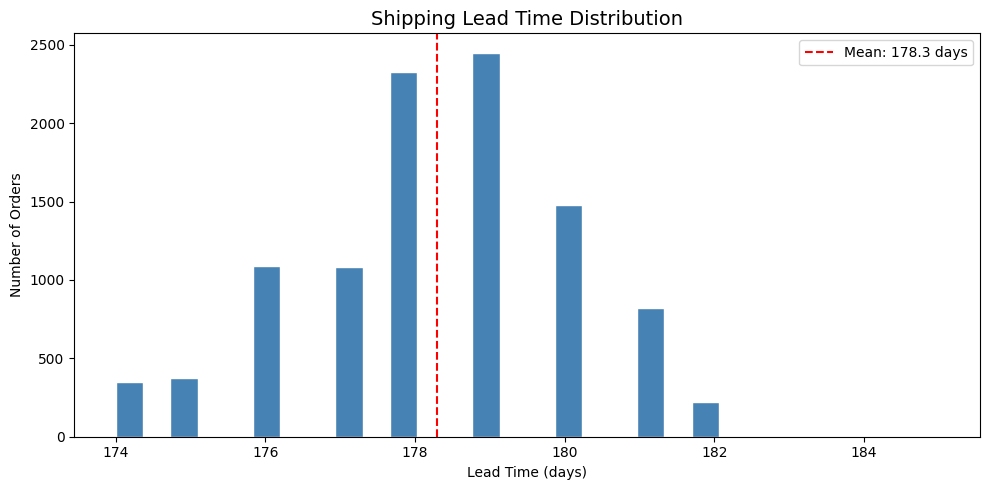

Chart 1 saved!


In [100]:
import matplotlib.pyplot as plt
import os

os.makedirs('charts', exist_ok=True)

# ── Chart 1: Histogram of Lead Times ──
plt.figure(figsize=(10, 5))
plt.hist(df['Lead Time'], bins=30, color='steelblue', edgecolor='white')
plt.axvline(df['Lead Time'].mean(), color='red', linestyle='--',
            label=f"Mean: {df['Lead Time'].mean():.1f} days")
plt.title('Shipping Lead Time Distribution', fontsize=14)
plt.xlabel('Lead Time (days)')
plt.ylabel('Number of Orders')
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart1_lead_time_hist.png')
plt.show()
print('Chart 1 saved!')


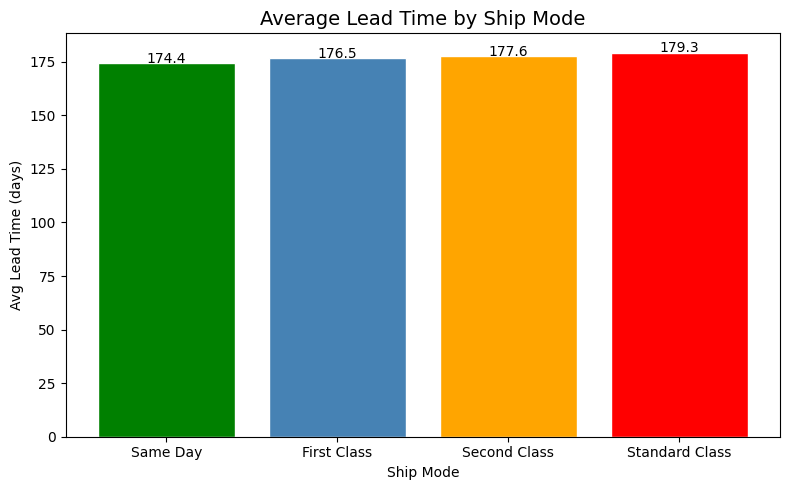

Chart 2 saved!


In [101]:
# ── Chart 2: Average Lead Time by Ship Mode ──
mode_avg = df.groupby('Ship Mode')['Lead Time'].mean().sort_values()

plt.figure(figsize=(8, 5))
bars = plt.bar(mode_avg.index, mode_avg.values,
               color=['green', 'steelblue', 'orange', 'red'],
               edgecolor='white')

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.05,
             f'{height:.1f}', ha='center', fontsize=10)

plt.title('Average Lead Time by Ship Mode', fontsize=14)
plt.xlabel('Ship Mode')
plt.ylabel('Avg Lead Time (days)')
plt.tight_layout()
plt.savefig('charts/chart2_shipmode_leadtime.png')
plt.show()
print('Chart 2 saved!')


In [102]:
# Get top 10 most efficient (lowest avg lead time)
top10 = route_kpi.head(10)

In [103]:
# Get bottom 10 least efficient (highest avg lead time)
bottom10 = route_kpi.tail(10).sort_values('Avg_Lead_Time', ascending=False)

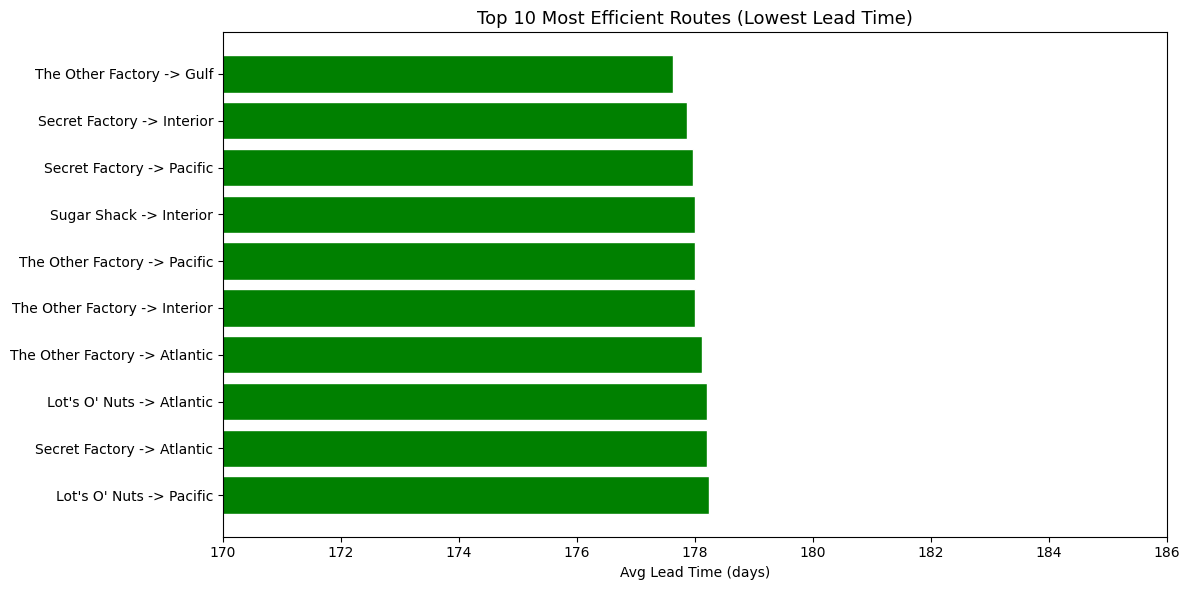

In [104]:
# ── Chart 3: Top 10 Most Efficient Routes ──
plt.figure(figsize=(12, 6))
plt.barh(top10['Route Region'], top10['Avg_Lead_Time'],
         color='green', edgecolor='white')
plt.gca().invert_yaxis()  # Best route at top
plt.title('Top 10 Most Efficient Routes (Lowest Lead Time)', fontsize=13)
plt.xlabel('Avg Lead Time (days)')
plt.xlim(170, 186)  
plt.tight_layout()
plt.savefig('charts/chart3_top10_routes.png')
plt.show()


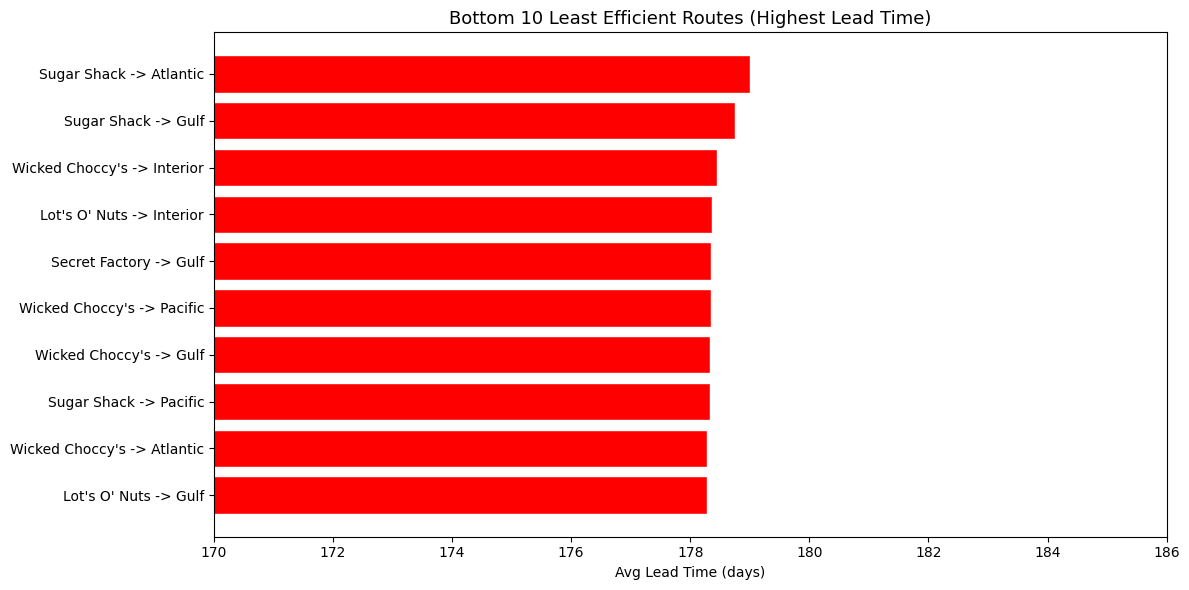

In [105]:
# ── Chart 4: Bottom 10 Least Efficient Routes ──
plt.figure(figsize=(12, 6))
plt.barh(bottom10['Route Region'], bottom10['Avg_Lead_Time'],
         color='red', edgecolor='white')
plt.gca().invert_yaxis()
plt.title('Bottom 10 Least Efficient Routes (Highest Lead Time)', fontsize=13)
plt.xlabel('Avg Lead Time (days)')
plt.xlim(170, 186)  
plt.tight_layout()
plt.savefig('charts/chart4_bottom10_routes.png')
plt.show()


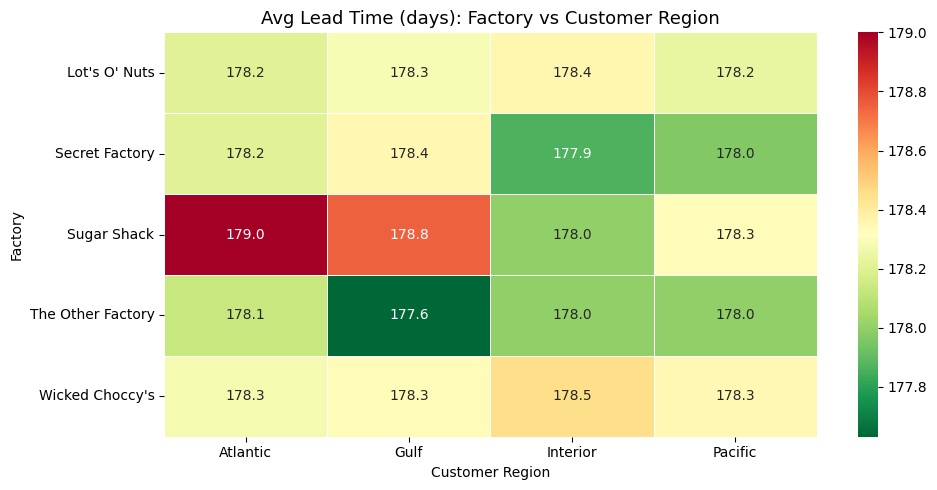

In [106]:
import seaborn as sns

# Create a pivot table: rows = Factory, columns = Region
# Values = average lead time
pivot = df.groupby(['Factory', 'Region'])['Lead Time'].mean().unstack()

# Draw the heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(
    pivot,
    annot=True,       # Show numbers inside cells
    fmt='.1f',        # 1 decimal place
    cmap='RdYlGn_r',  # Red = slow, Green = fast
    linewidths=0.5,
    linecolor='white'
)
plt.title('Avg Lead Time (days): Factory vs Customer Region', fontsize=13)
plt.ylabel('Factory')
plt.xlabel('Customer Region')
plt.tight_layout()
plt.savefig('charts/chart5_heatmap.png')
plt.show()


In [107]:
# Group by year and month
monthly = df.groupby(['Order Year', 'Order Month']).agg(
    Avg_Lead_Time = ('Lead Time', 'mean'),
    Total_Orders  = ('Lead Time', 'count'),
    Delay_Rate    = ('Is Delayed', 'mean')
).reset_index()

In [108]:
# Create a readable label like '2024-01', '2024-02'
monthly['Period'] = (monthly['Order Year'].astype(str) + '-' +
                     monthly['Order Month'].astype(str).str.zfill(2))
monthly = monthly.sort_values('Period')

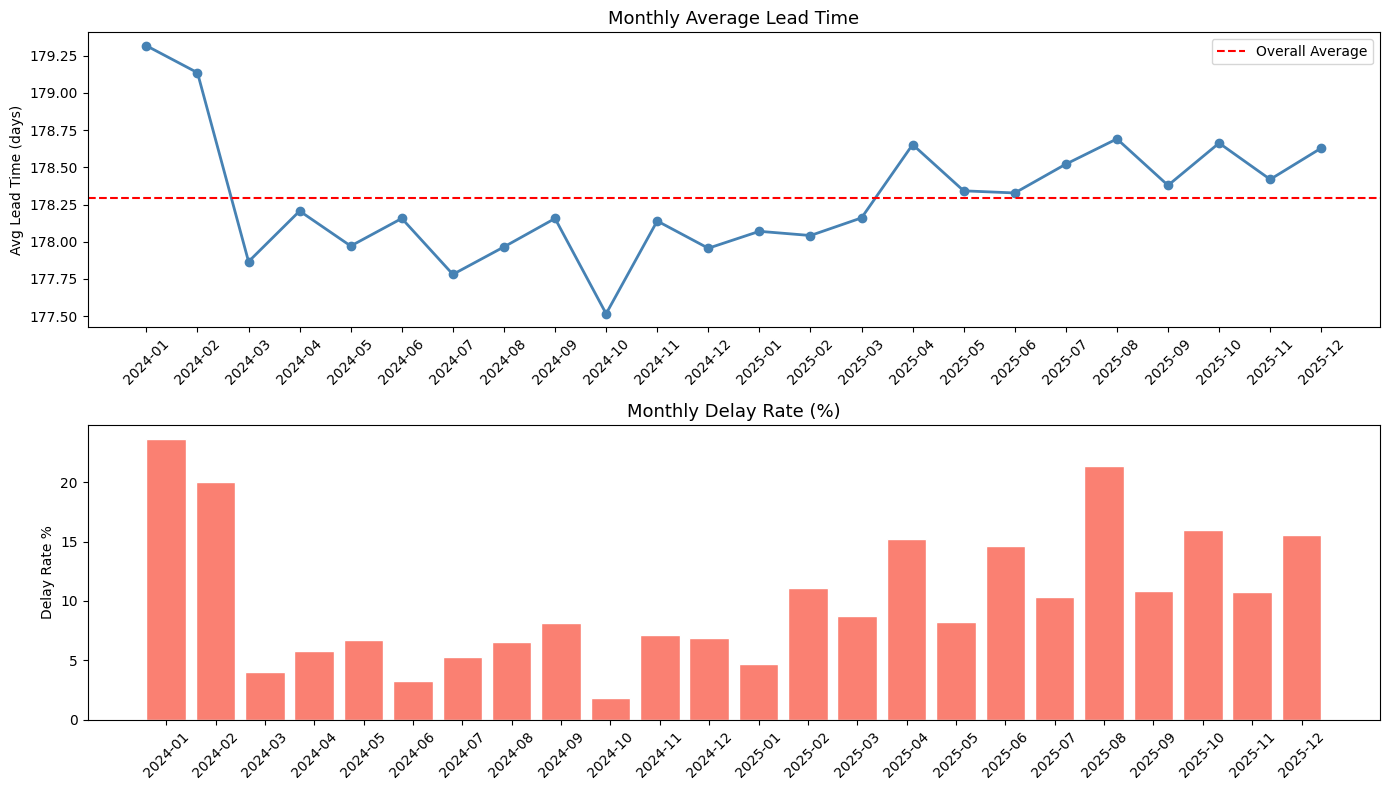

In [109]:
# ── Chart 6: Monthly Lead Time Trend ──
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top chart: average lead time each month
axes[0].plot(monthly['Period'], monthly['Avg_Lead_Time'],
             marker='o', color='steelblue', linewidth=2)
axes[0].axhline(df['Lead Time'].mean(), color='red',
                linestyle='--', label='Overall Average')
axes[0].set_title('Monthly Average Lead Time', fontsize=13)
axes[0].set_ylabel('Avg Lead Time (days)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Bottom chart: delay rate each month
axes[1].bar(monthly['Period'], monthly['Delay_Rate'] * 100,
            color='salmon', edgecolor='white')
axes[1].set_title('Monthly Delay Rate (%)', fontsize=13)
axes[1].set_ylabel('Delay Rate %')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('charts/chart6_monthly_trends.png')
plt.show()

In [110]:
# Group by state
state_data = df.groupby('State/Province').agg(
    Avg_Lead_Time  = ('Lead Time', 'mean'),
    Total_Orders   = ('Lead Time', 'count'),
    Delay_Rate     = ('Is Delayed', 'mean')
).reset_index()

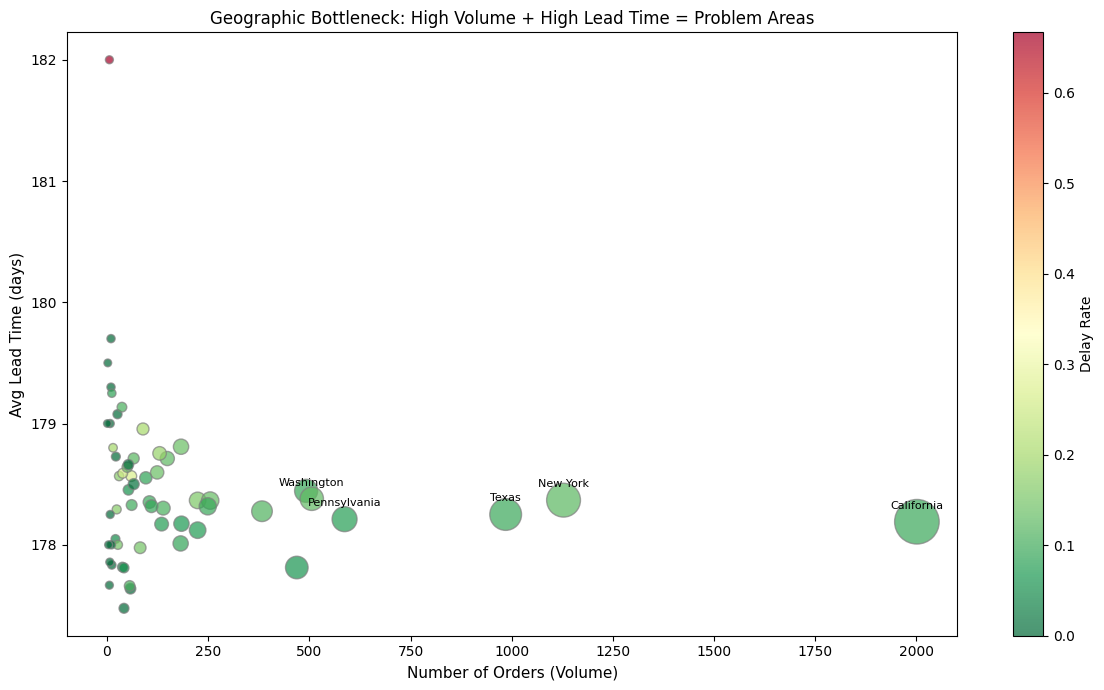

In [111]:
# ── Chart 7: Scatter — Volume vs Lead Time ──
plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    state_data['Total_Orders'],     # x axis = how many orders
    state_data['Avg_Lead_Time'],    # y axis = how slow
    c=state_data['Delay_Rate'],     # colour = delay rate
    cmap='RdYlGn_r',               # red = high delay
    s=state_data['Total_Orders'] * 0.5 + 30,  # size = volume
    alpha=0.7,
    edgecolors='grey'
)

plt.colorbar(scatter, label='Delay Rate')

# Label the 5 riskiest states (high orders + high lead time)
state_data['risk'] = state_data['Total_Orders'] * state_data['Avg_Lead_Time']
top5 = state_data.nlargest(5, 'risk')
for _, row in top5.iterrows():
    plt.annotate(row['State/Province'],
                 (row['Total_Orders'], row['Avg_Lead_Time']),
                 fontsize=8, ha='center', va='bottom',
                 xytext=(0, 8), textcoords='offset points')

plt.xlabel('Number of Orders (Volume)', fontsize=11)
plt.ylabel('Avg Lead Time (days)', fontsize=11)
plt.title('Geographic Bottleneck: High Volume + High Lead Time = Problem Areas',
          fontsize=12)
plt.tight_layout()
plt.savefig('charts/chart7_bottleneck.png')
plt.show()


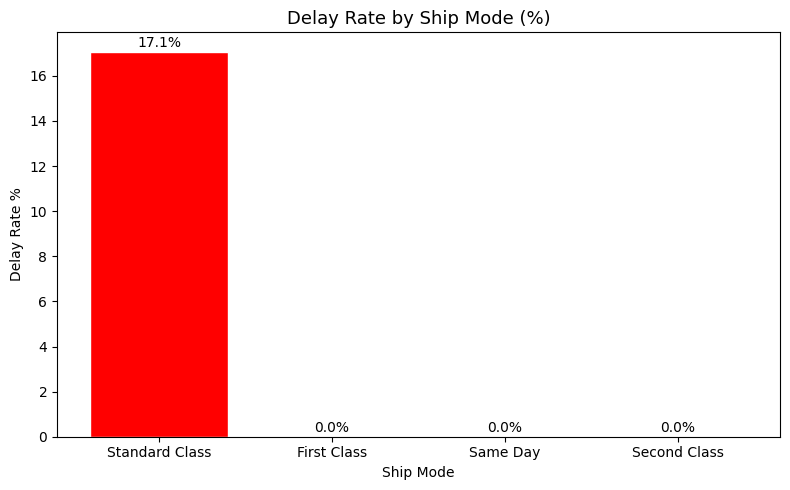

In [112]:
# ── Chart 8: Delay Rate by Ship Mode ──
mode_delay = df.groupby('Ship Mode')['Is Delayed'].mean() * 100
mode_delay = mode_delay.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(mode_delay.index, mode_delay.values,
        color=['red','orange','steelblue','green'], edgecolor='white')
plt.title('Delay Rate by Ship Mode (%)', fontsize=13)
plt.ylabel('Delay Rate %')
plt.xlabel('Ship Mode')
for i, val in enumerate(mode_delay.values):
    plt.text(i, val + 0.2, f'{val:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('charts/chart8_mode_delay.png')
plt.show()


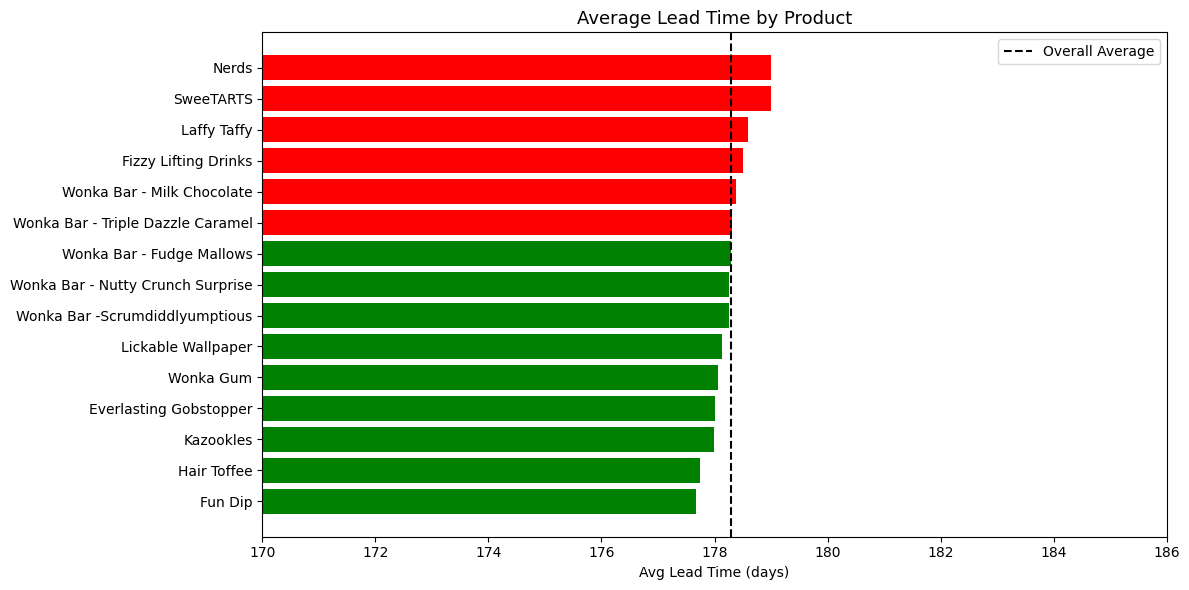

In [113]:
# ── Chart 9: Avg Lead Time by Product ──
product_lt = df.groupby('Product Name')['Lead Time'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(product_lt.index, product_lt.values,
         color=['red' if v > df['Lead Time'].mean() else 'green'
                for v in product_lt.values])
plt.axvline(df['Lead Time'].mean(), color='black',
            linestyle='--', label='Overall Average')
plt.title('Average Lead Time by Product', fontsize=13)
plt.xlabel('Avg Lead Time (days)')
plt.xlim(170, 186)  
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('charts/chart9_product_leadtime.png')
plt.show()
